In [15]:
import random
# iris dataset from sklearn
from sklearn.datasets import load_iris
from matplotlib import pyplot as plt
import numpy as np

data = load_iris()['data']
# Normalize each sample so distance is driven by direction/relative feature scale.
data = data/np.linalg.norm(data, axis=1).reshape(-1, 1)
data = [list(point) for point in list(data)]
targets = ["" for _ in range(len(data))]
num_clusters = 3
num_points = len(data)
num_features = len(data[0])


[[np.float64(0.7049512926353001), np.float64(0.3217874672489312), np.float64(0.5923597460283958), np.float64(0.21499323011471286)], [np.float64(0.7529051697005326), np.float64(0.34920790945026225), np.float64(0.5314959718116844), np.float64(0.16393735049213626)], [np.float64(0.8011397898889282), np.float64(0.5472692035395328), np.float64(0.23440877331300233), np.float64(0.03917808409420469)]]
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
{2: [[np.float64(0.8037727730153805), np.float64(0.5516087657948691), np.float64(0.2206435063179476), np.float64(0.03152050090256395)], [np.float64(0.828

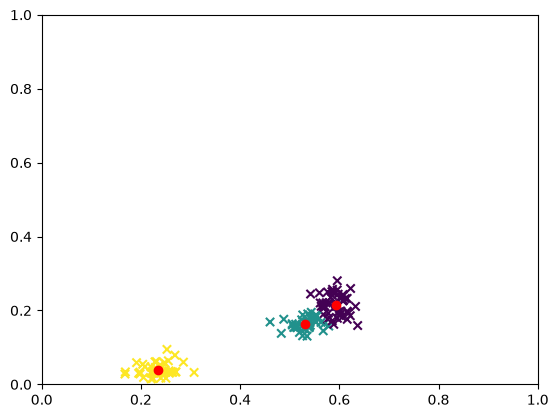

In [16]:
# 1) Initialization: pick K random data points as starting centroids.
centroids = random.sample(list(data), num_clusters)
for i in range(20):
    # 2) Assignment step: assign each point to its nearest centroid.
    closest_centroids={}
    for j , datum in enumerate(data):
        dist = []
        for centroid in centroids:
            distance = sum([(a-b)**2 for a,b in zip(datum, centroid)])
            dist.append(distance)
        
        # print(dist)
        
        closest_centroid = dist.index(min(dist))
        closest_centroids[closest_centroid] = closest_centroids.get(closest_centroid, []) + [datum]
        targets[j] = closest_centroid
        # print(f"datum {datum} assigned to centroid {closest_centroid} at {centroids[closest_centroid]}" )

    # 3) Update step: move each centroid to the mean of its assigned points.
    for x in  closest_centroids:
        new_centroid = ([sum(i)/len(closest_centroids[x]) for i in zip(*closest_centroids[x])])
        centroids[x] = new_centroid
    
    # 4) Convergence note: this version runs a fixed number of iterations (20)
    # instead of stopping early when centroid movement becomes very small.

print(centroids)
print(targets)
print(closest_centroids)

#marker style for each cluster

plt.scatter([i[2] for i in data], [i[3] for i in data], c=targets, marker='x')
plt.scatter([i[2] for i in centroids], [i[3] for i in centroids], c='r')
plt.xlim(0,1)
plt.ylim(0,1)
plt.show()
pass


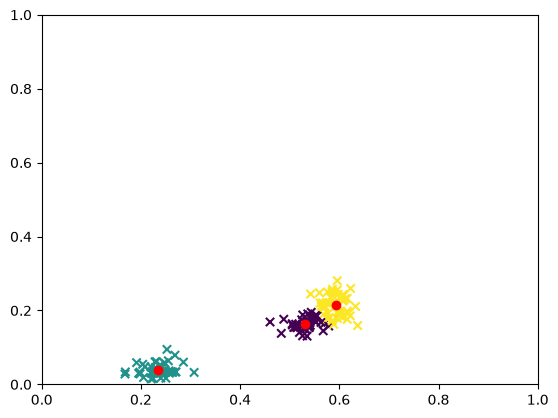

In [17]:
#use sklearn to do the same thing
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0).fit(data)
targets = kmeans.labels_
centroids = kmeans.cluster_centers_

plt.scatter([i[2] for i in data], [i[3] for i in data], c=targets, marker='x')
plt.scatter([i[2] for i in centroids], [i[3] for i in centroids], c='r')
plt.xlim(0,1)
plt.ylim(0,1)
plt.show()

In [18]:
# collaborative filtering, movie recommendation system, matrix factorization
movies = [
    "The Matrix",
    "Dune",
    "Titanic",
    "The Godfather",
    "The Shawshank Redemption"]

users = ["A", "B", "C"]

ratings = [
    [5, 4, 3, 4, 5],
    [4, 5, 4, 5, 4],
    [3, 4, 5, 4, 3]
]

n_embed = 4

import numpy as np
user_embeddings = np.random.rand(len(users), n_embed)
movie_embeddings = np.random.rand(len(movies), n_embed)

predicted_ratings = np.dot(user_embeddings, movie_embeddings.T)
rmse = np.sqrt(np.mean((predicted_ratings - ratings) ** 2))

print("RMSE:", rmse)

RMSE: 3.055223617466654


In [19]:
# minimize the RMSE by updating the embeddings using gradient descent
learning_rate = 0.01

for epoch in range(1000):
    predicted_ratings = np.dot(user_embeddings, movie_embeddings.T)
    error = predicted_ratings - ratings
    rmse = np.sqrt(np.mean(error ** 2))
    
    user_gradients = np.dot(error, movie_embeddings) / len(users)
    movie_gradients = np.dot(error.T, user_embeddings) / len(movies)
    
    user_embeddings -= learning_rate * user_gradients
    movie_embeddings -= learning_rate * movie_gradients
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, RMSE: {rmse}")

Epoch 0, RMSE: 3.055223617466654
Epoch 100, RMSE: 0.5495588073366765
Epoch 200, RMSE: 0.4460581610757839
Epoch 300, RMSE: 0.3100065631139711
Epoch 400, RMSE: 0.19230817532489505
Epoch 500, RMSE: 0.1196520921947795
Epoch 600, RMSE: 0.07848158590279362
Epoch 700, RMSE: 0.05334263308726174
Epoch 800, RMSE: 0.03673260037475064
Epoch 900, RMSE: 0.025370099409605985


In [20]:
user_embeddings@movie_embeddings.T

array([[4.99448003, 4.00301447, 2.98795161, 4.01540909, 4.99739334],
       [4.01364054, 4.9930391 , 4.03058418, 4.96043682, 4.00672346],
       [2.99044579, 4.00465569, 4.97821264, 4.02838024, 2.99516364]])

In [21]:
ratings

[[5, 4, 3, 4, 5], [4, 5, 4, 5, 4], [3, 4, 5, 4, 3]]